In [1]:
import LeafletSC
import sys
import numpy as np
import torch 
import pandas as pd
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap
import LeafletSC

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

2.3.0+cu121
12.1
2.3.0+cu121
12.1


<module 'factor_model' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py'>

In [2]:
# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations')
import masking
from masking import *

# import reload 
from importlib import reload
reload(masking)

<module 'masking' from '/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py'>

In [3]:
# Append this directory to sys.path
from LeafletSC.clustering.find_intron_clusters import visualize_local_events
from LeafletSC.beta_binomial_mix.modeling import *
from LeafletSC.beta_binomial_mix.calculate_cellstate_consistency import *
from LeafletSC.clustering.load_cluster_data import *
from LeafletSC.utils.helpers import * 
from LeafletSC.utils.visualization import *

In [4]:
# published metadata
metacells = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/human_MTG_2018-06-14_samples-columns.csv"
# read in metacells 
cells_pub = pd.read_csv(metacells)
cells_pub.head()

,sample_name,sample_id,sample_type,organism,donor,sex,age_days,brain_hemisphere,brain_region,brain_subregion,...,percent_mt_exon_reads,percent_reads_unique,percent_synth_reads,percent_ecoli_reads,percent_aligned_reads_total,complexity_cg,genes_detected_cpm_criterion,genes_detected_fpkm_criterion,class,cluster
0,F1S4_160106_001_B01,556012415,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.090052,85.573696,0.007535,0.018537,92.418885,0.316637,8635,5253,GABAergic,Inh L4-6 SST B3GAT2
1,F1S4_160106_001_C01,556012410,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.052470,87.619777,0.002790,0.007265,94.001319,0.287989,11697,8246,Glutamatergic,Exc L5-6 RORB TTC12
2,F1S4_160106_001_E01,556012412,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.042946,86.448562,0.004573,0.006413,92.871217,0.280933,12138,8467,Glutamatergic,Exc L5-6 FEZF2 ABO
3,F1S4_160106_001_G01,556012414,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.055851,84.497105,0.006585,0.008131,90.198132,0.293406,12191,8287,Glutamatergic,Exc L5-6 FEZF2 EFTUD1P1
4,F1S4_160106_001_H01,556012409,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.055692,87.014752,0.005061,0.011116,93.460676,0.293106,10535,6922,Glutamatergic,Exc L3-5 RORB ESR1


In [5]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


In [6]:
K = 10 

hypers = {
            "eta" : 1/K, # 1 or 1/K
            "alpha_prior" : 1., 
            "pi_prior" : 1. 
        }

In [7]:
# Define path that contains the model input files and append it (input can be a folder with one .h5 file per cell_type for example or one file)
model_input_file='/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/LeafletAnalysis/human_cortex_mtg_leaflet.h5'

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data(
     input_file = model_input_file, max_intron_count=100000, remove_singletons=True, has_genes="yes")

# add cluster information to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# generate torch tensors for sparse data representation 
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

# simplify columns 
simple_data = final_data[["cell_id_index", "Cluster", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

print("The number of junctions is: ", len(junction_ids_conversion))
print("The number of intron clusters observed is: ", len(junction_ids_conversion.Cluster.unique()))
print("The number of genes is: ", len(junction_ids_conversion.gene_id.unique()))
print("The number of cells is: ", len(simple_data.cell_id_index.unique()))

Reading in data from folder ...
Finished reading in data from folder ...
Removing singletons ...
Number of junctions before removing singletons:  12748
Number of junctions after removing singletons:  12748
The number of unique cell types in the data is:  4
The number of unique cells in the data is:  208
The number of unique junctions in the data is:  12749
The maximum junction count was initially:  5117
0
The maximum junction count is now:  5117
The number of junctions in the data is:  12749
The number of cells in the data is:  208
The number of cell types in the data is:  4
The number of cells going into training data is:
208
208
The number of junctions is:  12749
The number of intron clusters observed is:  4677
The number of genes is:  3297
The number of cells is:  208


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/LeafletSC/clustering/load_cluster_data.py:47: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount).to_sparse_csr()


### Evaluate performance on imputation/masking task

In [8]:
# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

In [9]:
#1. get masked matrix using intron cluster counts for this mouse brain data 
perc_mask = 0.15
seeds_used = []
masks_list = []

print("The masking percentage is: " + str(perc_mask))
masked_matrix, seed = generate_mask(cluster_counts, mask_percentage = perc_mask, randomize_seed = True)
seeds_used.append(seed)
masks_list.append(masked_matrix)

The masking percentage is: 0.15
The seed is:  645215
[ 77126 314404 430648 592203 432092 558575 485654  58153  15914 508979
 159080 471347 149333 321294 314966 147570 445649 450653 641476  37028
 128992  59587 609413 394264 401934 636883 586947  82845 374725 592090
 581361  38593 391572 514098 526870 141815 162227  19364 165770 534309
  18280 257574 227909 208643 189015 524287 486946 187931 571042 194190]
Number of entries (junction-cell pairs) masked:  96685.0


In [10]:
# get all C-J pairs where values in masked_matrix equal 1 these are the pairs we will remove from the final_data object 
# Find row-column index pairs corresponding to values of 1
indices = np.argwhere(masked_matrix == 1)
indices_df = pd.DataFrame(indices, columns=['cell_id_index', 'junction_id_index'])
indices_df['combined_index'] = indices_df.apply(lambda row: f"{row['cell_id_index']}_{row['junction_id_index']}", axis=1)

In [11]:
final_data['combined_index'] = final_data.apply(lambda row: f"{row['cell_id_index']}_{row['junction_id_index']}", axis=1)

In [12]:
# Filter the original DataFrame to exclude corresponding indices
filtered_df = final_data[~final_data['combined_index'].isin(indices_df.combined_index)]

In [13]:
#2. get junction and intron cluster count matrices via masked values 
masked_counts = []
i=0
print("The masking percentage is: " + str(perc_mask))
masked_junction_counts, masked_intron_clusts = apply_mask(junc_counts, cluster_counts, masks_list[i])
# appent masked junction and intron cluster counts to list
masked_counts.append((masked_junction_counts, masked_intron_clusts))

The masking percentage is: 0.15


In [14]:
#3. get input files for factor model (junction and intron cluster sparse tensor)
model_input_files = [] 
masked_junction_counts, masked_intron_clusts = masked_counts[i]

# get y_tensor and total_counts_tensor via prep_model_input function
#y_tensor, total_counts_tensor = prep_model_input(masked_junction_counts, masked_intron_clusts)
# append to model_input_files list
#model_input_files.append((y_tensor, total_counts_tensor))

# make input for model 
cell_index_tensor_filt, junc_index_tensor_filt, my_data_filt = make_torch_data(filtered_df, **float_type)
model_input_files.append(my_data_filt)

The number of cells going into training data is:
208
208


In [15]:
assert(filtered_df.cluster_count.min() > 0)

In [16]:
# Now can run factor model on masked data
Ks = [2, 5, 10, 20, 50, 100, 250, 500]

all_Ks_results = {}
# Seeds used for masking 
seeds_used 

num_iters = 100 
i=0 

for k in Ks:
    
    print("------------------------------------------------")
    print("Running factor model for K = " + str(k))
    print("------------------------------------------------")
    
    # now also iterate over masking percentages 
    print("The masking percentage is: " + str(perc_mask))
    # run factor model
    print(k)
    masked_results = calculate_CAVI(K=k, my_data=model_input_files[i], float_type=float_type, hypers = None, num_iterations = num_iters) 
    # save results to dictionary
    all_Ks_results[(k, perc_mask)] = masked_results

------------------------------------------------
Running factor model for K = 2
------------------------------------------------
The masking percentage is: 0.15
2
Initialize VI params
Initializing variational parameters with N = 208 cells and J = 12749 junctions


Running CAVI with unknown cell types (not predefined)
z and theta will be updated!
Got the initial ELBO ^
The tolerance is set to  0.001
Updating z and thetaI iteration #  1
Updating z and theta iteration #  2
Updating z and theta iteration #  3
Updating z and theta iteration #  4
ELBO converged @ -6888219.0 CAVI iteration # 4 complete
ELBO converged @ -6888219.0 CAVI iteration # 4 complete
Finished CAVI!
------------------------------------------------
Running factor model for K = 5
------------------------------------------------
The masking percentage is: 0.15
5
Initialize VI params
Initializing variational parameters with N = 208 cells and J = 12749 junctions
Running CAVI with unknown cell types (not predefined)
z and theta will be updated!
Got the initial ELBO ^
The tolerance is set to  0.001
Updating z and thetaI iteration #  1
Updating z and theta iteration #  2
Updating z and theta iteration #  3
Updating z and theta iteration #  4
Updating z and theta iteration #  5
Updating z

In [17]:
mask_matrix_used = masks_list[i]

In [18]:
# Get pearson correlation and l1 error between true and inferred parameters (PSI)
masked_perf = []

for k in Ks:
    print("Calculating performance for K = " + str(k) + " and masking percentage = " + str(perc_mask))
    masked_results = all_Ks_results[(k, perc_mask)]        

    K = k 

    # get scores 
    mask_matrix_used = masks_list[i]

    l1, l2, r, ll = evaluate_mixture_model(junc_counts, cluster_counts, masked_results, mask_matrix_used)

    # save to list 
    masked_perf.append([l1, l2, r, ll, K, perc_mask])

Calculating performance for K = 2 and masking percentage = 0.15
Calculating performance for K = 5 and masking percentage = 0.15
Calculating performance for K = 10 and masking percentage = 0.15
Calculating performance for K = 20 and masking percentage = 0.15
Calculating performance for K = 50 and masking percentage = 0.15
Calculating performance for K = 100 and masking percentage = 0.15
Calculating performance for K = 250 and masking percentage = 0.15
Calculating performance for K = 500 and masking percentage = 0.15


In [19]:
masked_perf_df = pd.DataFrame(masked_perf, columns=["l1", "l2", "r", "ll", "K",  "perc_masked"])
# Assuming df is your DataFrame
masked_perf_df['l1'] = masked_perf_df['l1'].astype(float)
masked_perf_df['l2'] = masked_perf_df['l2'].astype(float)
masked_perf_df

,l1,l2,r,ll,K,perc_masked
0,0.270898,0.355234,0.518852,-4.939973e+05,2,0.15
1,0.273783,0.368793,0.481327,-5.462837e+05,5,0.15
2,0.279843,0.382090,0.449163,-5.977448e+05,10,0.15
3,0.295518,0.398419,0.401001,-6.554190e+05,20,0.15
4,0.319383,0.408183,0.351681,-7.892283e+05,50,0.15
5,0.330705,0.413380,0.325244,-1.048502e+06,100,0.15
6,0.306102,0.399189,0.384543,-8.841446e+05,250,0.15
7,0.298023,0.386809,0.417511,-7.406256e+05,500,0.15


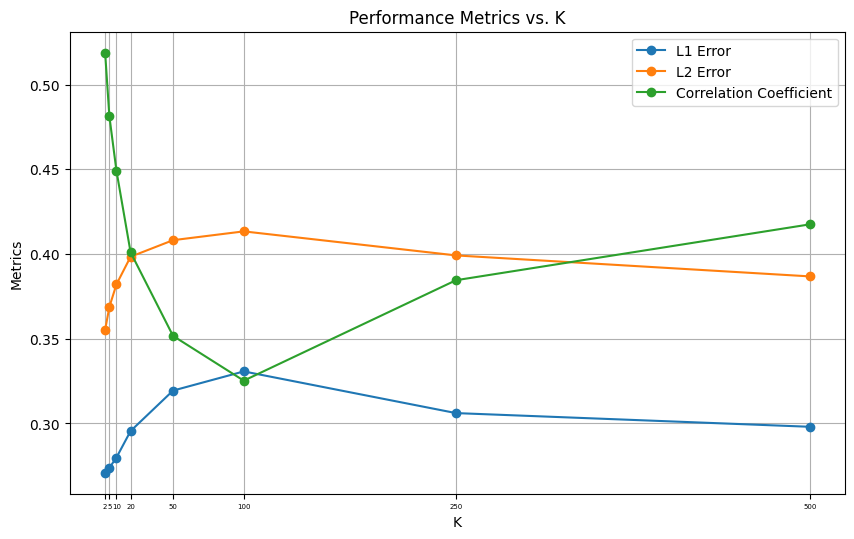

In [20]:
plt.figure(figsize=(10, 6))

# L1 Error
plt.plot(masked_perf_df["K"], masked_perf_df["l1"], marker='o', label='L1 Error')

# L2 Error
plt.plot(masked_perf_df["K"], masked_perf_df["l2"], marker='o', label='L2 Error')

# Correlation Coefficient
plt.plot(masked_perf_df["K"], masked_perf_df["r"], marker='o', label='Correlation Coefficient')

# Labels and Title
plt.xlabel('K')
plt.ylabel('Metrics')
plt.title('Performance Metrics vs. K')
plt.xticks(masked_perf_df["K"], size=5)
plt.legend()
plt.grid(True)

plt.show()

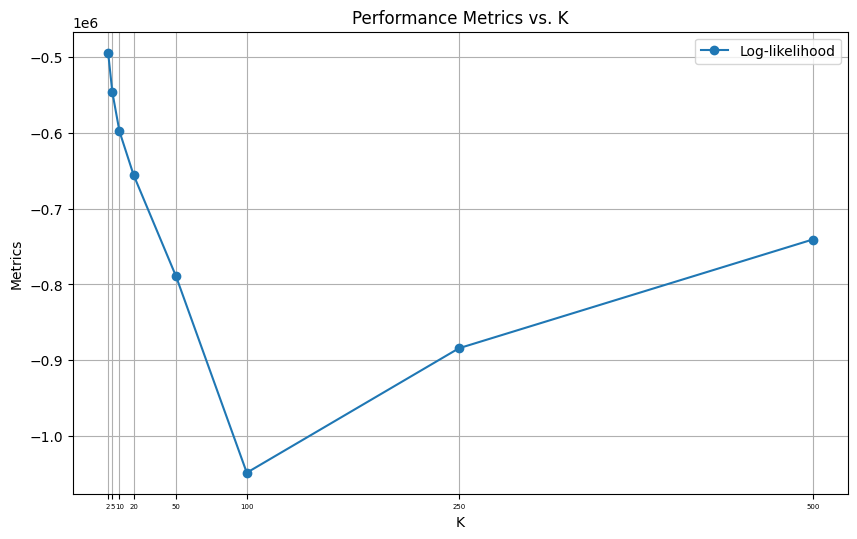

In [21]:
# Plotting
plt.figure(figsize=(10, 6))

# Log-likelihood
plt.plot(masked_perf_df["K"], masked_perf_df["ll"], marker='o', label='Log-likelihood')

# Labels and Title
plt.xlabel('K')
plt.ylabel('Metrics')
plt.title('Performance Metrics vs. K')
plt.xticks(masked_perf_df["K"], size=5)
plt.legend()
plt.grid(True)

plt.show()

### Run full model

In [64]:
num_trials = 500 # should also be an argument that gets fed in
num_iters = 100 # should also be an argument that gets fed in
K = 20
print("The K used is: ", K)
results = [ calculate_CAVI(K, my_data, float_type, hypers, num_iterations = num_iters, fixed_cell_types = False) 
           for t in range(num_trials) ]

The K used is:  20
Initialize VI params
Initializing variational parameters with N = 208 cells and J = 12749 junctions
Running CAVI with unknown cell types (not predefined)
z and theta will be updated!
Got the initial ELBO ^
The tolerance is set to  0.001
Updating z and thetaI iteration #  1
Updating z and theta iteration #  2
Updating z and theta iteration #  3
Updating z and theta iteration #  4
ELBO converged @ -7600599.0 CAVI iteration # 4 complete
ELBO converged @ -7600599.0 CAVI iteration # 4 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 208 cells and J = 12749 junctions
Running CAVI with unknown cell types (not predefined)
z and theta will be updated!
Got the initial ELBO ^
The tolerance is set to  0.001
Updating z and thetaI iteration #  1
Updating z and theta iteration #  2
Updating z and theta iteration #  3
Updating z and theta iteration #  4
ELBO converged @ -7598462.0 CAVI iteration # 4 complete
ELBO converged @ -7598462.0 CAVI i

In [65]:
best = np.argmax([ g[-1][-1] for g in results ]) # final ELBO
print(f"The trial with the highest ELBO was {best}")
ALPHA_f, PI_f, GAMMA_f, PHI_f, elbos_all = results[best]
elbos_all = np.array(elbos_all)
elbos_all

The trial with the highest ELBO was 357


array([-37028480. ,  -8443193. ,  -7585835. ,  -7583251.5,  -7583250.5,
        -7583250.5])

In [66]:
# Calculate the total sum of the tensor values
total_sum = torch.sum(GAMMA_f)

# Calculate the percentages
percentages = (GAMMA_f / total_sum) 

# Convert the tensor to a dataframe 
GAMMA_f_plot = pd.DataFrame(percentages.cpu().numpy())
# Give it a colname called theta 
GAMMA_f_plot.columns = ["theta"]
GAMMA_f_plot["cell_state"] = GAMMA_f_plot.index
GAMMA_f_plot.sort_values(by="theta", ascending=False, inplace=True)
GAMMA_f_plot["new_cell_state"] = np.arange(GAMMA_f_plot.shape[0])

sorted_cell_states = GAMMA_f_plot["new_cell_state"].astype(str)

GAMMA_f_plot["new_cell_state"] = pd.Categorical(sorted_cell_states, sorted_cell_states.unique())
GAMMA_f_plot = GAMMA_f_plot.sort_values(by='new_cell_state')

# Create a color mapping for each unique cellassignment
unique_states = GAMMA_f_plot['new_cell_state'].unique()
palette = sns.color_palette("colorblind", len(unique_states))
color_mapping = dict(zip(unique_states, palette))

In [67]:
juncs_probs = ALPHA_f / (ALPHA_f+PI_f)   
alpha_plus_pi = ALPHA_f+PI_f

juncs_probs.shape

torch.Size([12749, 20])

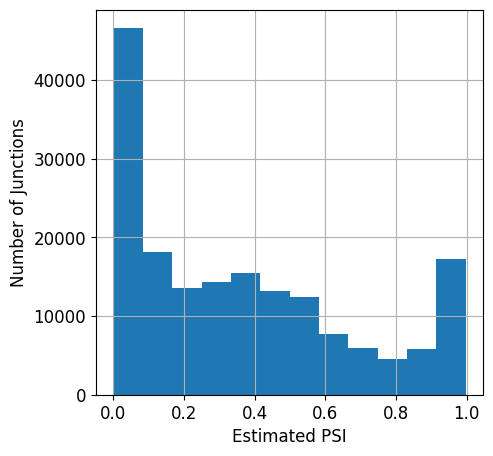

In [68]:
# Create boolean mask from tensor1
mask = alpha_plus_pi >= 10

# Apply the mask to tensor2 to get filtered values
filtered_values = juncs_probs[mask]

plt.figure(figsize=(5, 5))
# Plot the values
plt.hist(filtered_values.numpy(), bins=12)  # Assuming you want a histogram, adjust as needed
plt.xlabel('Estimated PSI', fontsize=12)
# Set y-label with larger font size (if you need it)
plt.ylabel('Number of Junctions', fontsize=12)  
# Increase tick label size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# add grid 
plt.grid()

In [69]:
juncs_probs_df = pd.DataFrame(juncs_probs, columns = range(K))
juncs_probs_df["junction_id_index"] = junction_ids_conversion.junction_id_index.values
# convert to juncs_probs to pandas dataframe and calculate mean and std across cell states/topics
juncs_probs_df["junction_id"] = junction_ids_conversion.junction_id.values
juncs_probs_df.head()

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,junction_id_index,junction_id
0,0.500000,0.100000,0.555556,0.500000,0.857143,0.900000,0.090909,0.888889,0.692308,0.714286,...,0.500000,0.909091,0.750000,0.400000,0.933333,0.500000,0.500000,0.850000,0,1_150150287_150150911
1,0.500000,0.018519,0.007812,0.100000,0.090909,0.100000,0.011905,0.016949,0.026316,0.005181,...,0.166667,0.087302,0.909091,0.108108,0.009346,0.250000,0.500000,0.054795,1,1_150151058_150158818
2,0.285714,0.013158,0.319728,0.547445,0.229358,0.705882,0.671141,0.313131,0.688312,0.650000,...,0.425743,0.609195,0.521739,0.140625,0.142857,0.317308,0.461538,0.688742,2,1_69678478_69760190
3,0.500000,0.454545,0.485714,0.250000,0.071429,0.272727,0.666667,0.428571,0.166667,0.500000,...,0.400000,0.833333,0.833333,0.933333,0.571429,0.571429,0.309091,0.400000,3,1_16970767_16971464
4,0.500000,0.273973,0.243243,0.076923,0.350000,0.434783,0.500000,0.909091,0.500000,0.055556,...,0.500000,0.100000,0.777778,0.500000,0.318182,0.500000,0.500000,0.125000,4,1_172551626_172553259


In [70]:
scores_all_juncs = []

for junc_index in range(juncs_probs.shape[0]):
    a = ALPHA_f[junc_index, [0, 1]]
    b = PI_f[junc_index, [0, 1] ]
    scores_all_juncs.append(score(a, b).item())

# turn scores_all_juncs into dataframe and add junction_id_index as a column
scores_all_juncs_df = pd.DataFrame(scores_all_juncs, columns = ["score"])
scores_all_juncs_df["junction_id_index"] = junction_ids_conversion.junction_id_index.values

In [71]:
# Compute the logistic score
scores_all_juncs_df["logistic_score"] = 1 / (1 + np.exp(-scores_all_juncs_df["score"].values))

# Compute the Bayesian q-value for FDR
scores_all_juncs_df["q_value"] = 1 - scores_all_juncs_df["logistic_score"].values 
scores_all_juncs_df["significance"] = np.where(scores_all_juncs_df["q_value"].values < 0.01, "yes", "no")

In [72]:
scores_all_juncs_df["significance"].value_counts()

significance
no     10156
yes     2593
Name: count, dtype: int64

In [73]:
# merge scores_all_juncs_df with junction_ids_conversion to get gene_id and junction_id 
scores_all_juncs_df = scores_all_juncs_df.merge(junction_ids_conversion, on="junction_id_index")
scores_all_juncs_df.sort_values(by="score", ascending=False).head(10)

,score,junction_id_index,logistic_score,q_value,significance,junction_id,Cluster,gene_id
2544,166.564575,2544,1.0,0.0,yes,14_73099750_73103191,4459,ENSG00000119707.14
677,125.321289,677,1.0,0.0,yes,6_135492291_135497582,2419,ENSG00000135541.22
758,98.221313,758,1.0,0.0,yes,7_35145090_35150087,2813,ENSG00000291133.1
4020,88.791229,4020,1.0,0.0,yes,6_6564388_6622631,2471,ENSG00000216863.11
2543,84.729614,2543,1.0,0.0,yes,14_73099750_73100300,4459,ENSG00000119707.14
8126,84.065872,8126,1.0,0.0,yes,10_119061328_119069445,3493,ENSG00000107581.14
8345,82.400696,8345,1.0,0.0,yes,5_93964523_94053125,2068,ENSG00000113391.19
8178,80.706490,8178,1.0,0.0,yes,15_74905231_74906586,4835,ENSG00000178761.15
877,75.581665,877,1.0,0.0,yes,9_40244515_40248466,3218,ENSG00000291287.1
876,75.581665,876,1.0,0.0,yes,9_40244515_40248463,3218,ENSG00000291287.1


In [74]:
junc = 162
clust = get_cluster(junc, junction_ids_conversion)
gene = get_gene(junc, junction_ids_conversion)
print(f"The cluster is {clust} and the gene is {gene}")

The cluster is 650 and the gene is ENSG00000075292.19


In [75]:
simple_data_human = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

In [76]:
# summarize total number of junctions that are significantly differentially spliced between the two
# cell types of interest and also the number of unique genes they belong to

print("The number of junctions that are significantly differentially spliced between the two cell types is: ", scores_all_juncs_df["significance"].value_counts()["yes"])
print("The number of unique genes that these junctions belong to is: ", scores_all_juncs_df[scores_all_juncs_df["significance"]=="yes"]["gene_id"].nunique())

The number of junctions that are significantly differentially spliced between the two cell types is:  2593
The number of unique genes that these junctions belong to is:  1119


In [77]:
# print the gene that has the most number of junctions that are significantly differentially spliced between the two cell types
gene_counts = scores_all_juncs_df[scores_all_juncs_df["significance"]=="yes"]["gene_id"].value_counts()

# print the top 5 genes with the most DS junctions
print("The top 5 genes with the most number of junctions that are significantly differentially spliced between the two cell types are: ")
print(gene_counts.head(5))

The top 5 genes with the most number of junctions that are significantly differentially spliced between the two cell types are: 
gene_id
ENSG00000135976.21    28
ENSG00000174501.15    26
ENSG00000215126.12    10
ENSG00000291133.1      9
ENSG00000178761.15     8
Name: count, dtype: int64


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


tensor([0.0386, 0.0576, 0.0719, 0.0433, 0.0386, 0.0481, 0.0576, 0.0671, 0.0481,
        0.0386, 0.0576, 0.0529, 0.0624, 0.0814, 0.0433, 0.0243, 0.0290, 0.0433,
        0.0290, 0.0671])


/scratch/ipykernel_151234/1151143128.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="new_cell_state", y="theta", data=GAMMA_f_plot, palette=color_mapping)
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


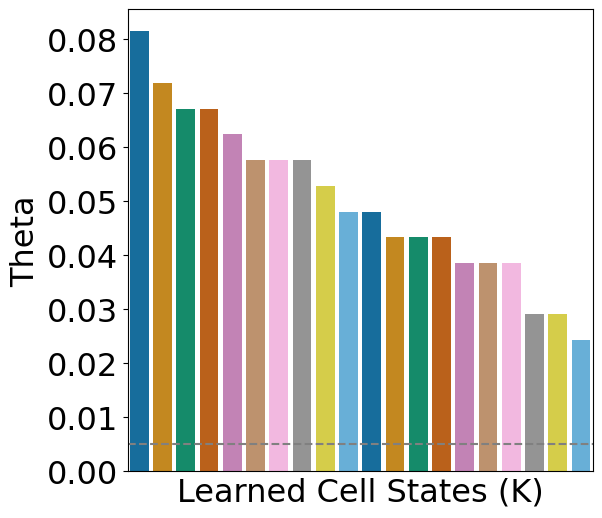

In [78]:
total_sum = torch.sum(GAMMA_f)

# Calculate the percentages
percentages = (GAMMA_f / total_sum) 
print(percentages)

# Convert the tensor to a dataframe 
GAMMA_f_plot = pd.DataFrame(percentages.cpu().numpy())
# Give it a colname called theta 
GAMMA_f_plot.columns = ["theta"]
GAMMA_f_plot["cell_state"] = GAMMA_f_plot.index
GAMMA_f_plot.sort_values(by="theta", ascending=False, inplace=True)
GAMMA_f_plot["new_cell_state"] = np.arange(GAMMA_f_plot.shape[0])

sorted_cell_states = GAMMA_f_plot["new_cell_state"].astype(str)

GAMMA_f_plot["new_cell_state"] = pd.Categorical(sorted_cell_states, sorted_cell_states.unique())
GAMMA_f_plot = GAMMA_f_plot.sort_values(by='new_cell_state')

# Create a color mapping for each unique cellassignment
unique_states = GAMMA_f_plot['new_cell_state'].unique()
palette = sns.color_palette("colorblind", len(unique_states))
color_mapping = dict(zip(unique_states, palette))

# Make barplot using sns
plt.figure(figsize=(6, 6))
sns.barplot(x="new_cell_state", y="theta", data=GAMMA_f_plot, palette=color_mapping)
plt.axhline(0.005, ls='--', color='grey')

# Make Y label say Theta and increase font of all labels and ticks
plt.ylabel("Theta", fontsize=23)
plt.xlabel("Learned Cell States (K)", fontsize=23)
plt.xticks([])
plt.yticks(fontsize=23)
plt.show()

In [79]:
cell_types_summary=cell_ids_conversion['cell_type'].value_counts()
cell_types_summary=pd.DataFrame(cell_types_summary)
cell_types_summary.reset_index(inplace=True)
cell_types_summary.columns=['cell_type','count']

# get percentage of each cell type in the data 
cell_types_summary['percentage']=cell_types_summary['count']/cell_types_summary['count'].sum()
cell_types_summary.sort_values(by='percentage',ascending=False,inplace=True)
print(cell_types_summary)

       cell_type  count  percentage
0  Glutamatergic     92    0.442308
1       no class     65    0.312500
2      GABAergic     49    0.235577
3   Non-neuronal      2    0.009615


(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.1, '0.1'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.30000000000000004, '0.3'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.5, '0.5')])

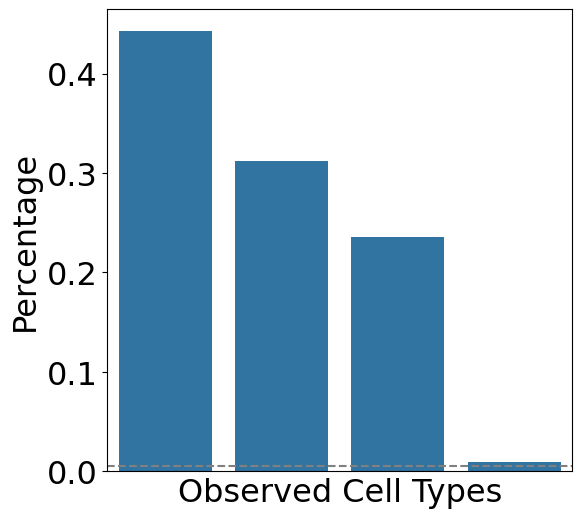

In [80]:
# Create the barplot using the cell_type_colors palette
plt.figure(figsize=(6, 6))
sns.barplot(x="cell_type", y="percentage", data=cell_types_summary)
plt.axhline(0.005, ls='--', color='grey')
plt.ylabel("Percentage", fontsize=23)
plt.xlabel("Observed Cell Types", fontsize=23)
plt.xticks([])
plt.yticks(fontsize=23)

In [81]:
# convert PHI_f to a dataframe and add a column with cell ID and cell type 
PHI_f = pd.DataFrame(PHI_f)

In [82]:
# Add "CellState" to each column 
PHI_f.columns = ["CellState_" + str(i+1) for i in range(PHI_f.shape[1])]
PHI_f['cell_id'] = cell_ids_conversion.cell_id.values
PHI_f['cell_type'] = cell_ids_conversion.cell_type.values
PHI_f

,CellState_1,CellState_2,CellState_3,CellState_4,CellState_5,CellState_6,CellState_7,CellState_8,CellState_9,CellState_10,...,CellState_13,CellState_14,CellState_15,CellState_16,CellState_17,CellState_18,CellState_19,CellState_20,cell_id,cell_type
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,F2S4_170405_005_A01,no class
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,F2S4_170405_005_B01,no class
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,F2S4_170405_005_C01,no class
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,F2S4_170405_005_D01,Glutamatergic
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,F2S4_170405_005_E01,Glutamatergic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,F2S4_170405_032_C01,Glutamatergic
204,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,F2S4_170405_032_E01,Glutamatergic
205,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,F2S4_170405_032_F01,GABAergic
206,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,F2S4_170405_032_G01,Glutamatergic


In [83]:
from scipy.stats import fisher_exact

PHI_f_melt = pd.melt(PHI_f, id_vars=['cell_id', 'cell_type'], value_vars=PHI_f.columns[:-2])

# for each cell, choose cell state with highest probability
PHI_f_melt = PHI_f_melt.sort_values(by=['cell_id', 'value'], ascending=False).drop_duplicates(subset=['cell_id'])
PHI_f_melt.head()

from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(PHI_f_melt['variable'], PHI_f_melt['cell_type'])
contingency_table

cell_type,GABAergic,Glutamatergic,Non-neuronal,no class
variable,,,,
CellState_1,3,4,0,1
CellState_10,4,1,1,2
CellState_11,4,5,0,3
CellState_12,5,4,0,2
CellState_13,2,6,0,5
CellState_14,0,9,0,8
CellState_15,3,4,0,2
CellState_16,0,2,1,2
CellState_17,2,2,0,2


Text(0.5, 36.72222222222228, '')

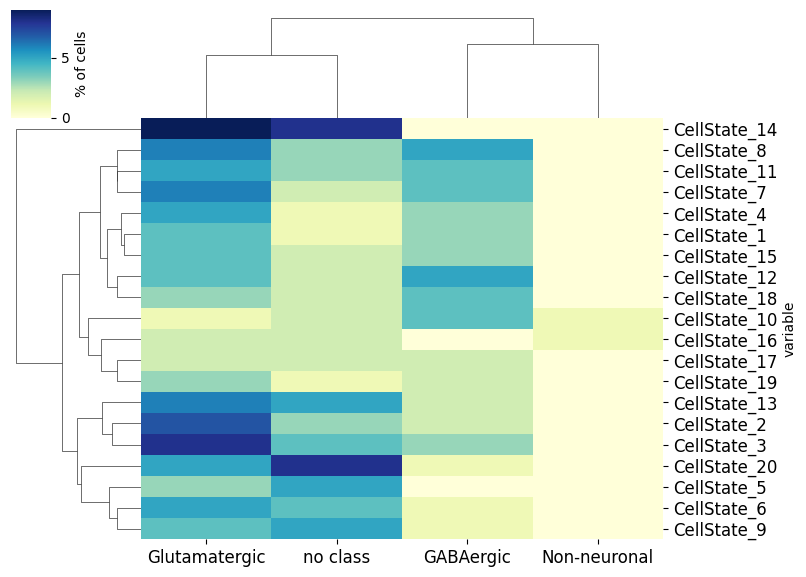

In [89]:
# plot clustermap of contingency table
g = sns.clustermap(contingency_table, cmap="YlGnBu", 
                   figsize=(8, 6), annot=False, fmt='.2f',
                   annot_kws={"size": 10}, cbar_kws={'label': '% of cells'})
# Increase the font size of the x-axis and y-axis tick labels
plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=12) # Set x-axis label size
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=12) # Set y-axis label size
# remove x lab 
g.ax_heatmap.set_xlabel("")